# 01 — Data Audit and EDA

This notebook loads the untouched Seattle dataset, audits its quality, identifies leakage-prone variables, and performs initial exploratory analysis.

### Imports — why this cell is needed
Loads the libraries used for the raw-data audit and exploratory analysis.

In [1]:
import re
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

### Repository paths — why this cell is needed
Uses only paths relative to the repository structure required by the faculty.

In [2]:
def find_repo_root():
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError(
        "Repository root not found. Run this notebook from inside the cloned "
        "CSE437 repository, with data/ and notebooks/ folders present."
    )

ROOT = find_repo_root()
RAW_DIR = ROOT / "data" / "raw"
PROCESSED_DIR = ROOT / "data" / "processed"
FIGURES_DIR = ROOT / "figures"
MODELS_DIR = ROOT / "models"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Repository root:", ROOT)

Repository root: /content/cse437-building-energy-G9


### Load the untouched raw dataset — why this cell is needed
Reads the original CSV from `data/raw/` without modifying it.

In [3]:
csv_files = sorted(RAW_DIR.glob("*.csv"))
if not csv_files:
    raise FileNotFoundError(
        "No CSV was found in data/raw/. Put the original Seattle CSV there first."
    )

RAW_CSV = csv_files[0]
df_raw = pd.read_csv(RAW_CSV, low_memory=False)

print("Loaded:", RAW_CSV.name)
print("Raw shape:", df_raw.shape)
display(df_raw.head())

Loaded: teqw-tu6e.csv
Raw shape: (38309, 46)


,osebuildingid,datayear,buildingname,buildingtype,taxparcelidentificationnumber,address,city,state,zipcode,latitude,...,electricity_kwh,steamuse_kbtu,naturalgas_therms,compliancestatus,complianceissue,electricity_kbtu,naturalgas_kbtu,totalghgemissions,ghgemissionsintensity,demolished
0,1,2025,Mayflower Park Hotel,NonResidential,659000030,405 OLIVE WAY,SEATTLE,WA,98101,47.612199,...,1021340.0,NaN,16927.4,Not Compliant,NaN,3484810.7,1692740.0,NaN,NaN,False
1,2,2025,Paramount Hotel,NonResidential,659000220,724 PINE ST,SEATTLE,WA,98101,47.613073,...,775602.0,NaN,34847.0,Compliant,No Issue,2646356.0,3484730.0,199.75,2.26,False
2,3,2025,Westin Hotel (Parent Building),NonResidential,659000475,1900 5TH AVE,SEATTLE,WA,98101,47.613672,...,11693500.0,29336926.0,51470.0,Compliant,No Issue,39898222.0,5147040.0,2880.50,3.48,False
3,5,2025,Hotel Max,NonResidential,659000640,620 STEWART ST,SEATTLE,WA,98101,47.614121,...,772199.0,1349793.0,11410.0,Compliant,No Issue,2634742.0,1141040.0,184.94,3.02,False
4,8,2025,Warwick Seattle Hotel,NonResidential,659000970,401 LENORA ST,SEATTLE,WA,98121,47.613950,...,1394922.0,NaN,58654.0,Compliant,No Issue,4759474.0,5865420.0,338.20,2.74,False


## Data audit

### Raw shape, duplicates, and missingness — why this cell is needed
Documents the condition of the original real-world dataset before any cleaning.

In [4]:
print("Rows:", df_raw.shape[0])
print("Columns:", df_raw.shape[1])
print("Exact duplicate rows:", df_raw.duplicated().sum())

raw_audit = pd.DataFrame({
    "Data Type": df_raw.dtypes.astype(str),
    "Missing Count": df_raw.isna().sum(),
    "Missing %": (df_raw.isna().mean() * 100).round(2),
    "Unique Values": df_raw.nunique(dropna=True)
}).sort_values("Missing %", ascending=False)

display(raw_audit)

Rows: 38309
Columns: 46
Exact duplicate rows: 0


,Data Type,Missing Count,Missing %,Unique Values
steamuse_kbtu,float64,37016,96.62,1293
thirdlargestpropertyusetypegfa,float64,30256,78.98,1233
thirdlargestpropertyusetype,object,29200,76.22,57
secondlargestpropertyuse,float64,17818,46.51,2855
secondlargestpropertyusetype,object,15937,41.60,67
naturalgas_therms,float64,14829,38.71,16741
naturalgas_kbtu,float64,14822,38.69,23167
energystarscore,float64,10417,27.19,100
siteeuiwn_kbtu_sf,float64,1961,5.12,3260
sourceeuiwn_kbtu_sf,float64,1961,5.12,5256


### Resolve important columns and leakage fields — why this cell is needed
Finds the real Seattle column names and identifies variables that must not be used as predictors.

In [5]:
def normalize_name(name):
    return re.sub(r"[^a-z0-9]", "", str(name).lower())

norm_map = {normalize_name(c): c for c in df_raw.columns}

def find_column(aliases, required=False):
    for alias in aliases:
        key = normalize_name(alias)
        if key in norm_map:
            return norm_map[key]
    if required:
        raise KeyError(
            f"Required column not found. Tried: {aliases}\n"
            f"Available columns: {list(df_raw.columns)}"
        )
    return None

TARGET_RAW = find_column(
    ["SiteEUI(kBtu/sf)", "SiteEUI", "siteeui_kbtu_sf"],
    required=True
)
GROUP_RAW = find_column(
    ["OSEBuildingID", "OSE Building ID", "osebuildingid"],
    required=True
)

COMPLIANCE_RAW = find_column(
    ["ComplianceStatus", "compliancestatus"]
)
COMPLIANCE_ISSUE_RAW = find_column(
    ["ComplianceIssue", "complianceissue"]
)
DEMOLISHED_RAW = find_column(
    ["Demolished", "demolished"]
)

FEATURE_ALIASES = {
    "DataYear": ["DataYear", "datayear"],
    "BuildingType": ["BuildingType", "buildingtype"],
    "EPAPropertyType": ["EPAPropertyType", "epapropertytype"],
    "LargestPropertyUseType": [
        "LargestPropertyUseType", "largestpropertyusetype"
    ],
    "SecondLargestPropertyUseType": [
        "SecondLargestPropertyUseType", "secondlargestpropertyusetype"
    ],
    "ThirdLargestPropertyUseType": [
        "ThirdLargestPropertyUseType", "thirdlargestpropertyusetype"
    ],
    "Neighborhood": ["Neighborhood", "neighborhood"],
    "CouncilDistrictCode": [
        "CouncilDistrictCode", "councildistrictcode"
    ],
    "ZipCode": ["ZipCode", "zipcode"],
    "YearBuilt": ["YearBuilt", "yearbuilt"],
    "NumberofFloors": ["NumberofFloors", "numberoffloors"],
    "NumberofBuildings": ["NumberofBuildings", "numberofbuildings"],
    "PropertyGFATotal": ["PropertyGFATotal", "propertygfatotal"],
    "PropertyGFABuilding": [
        "PropertyGFABuilding(s)", "PropertyGFABuilding",
        "propertygfabuildings"
    ],
    "PropertyGFAParking": [
        "PropertyGFAParking", "propertygfaparking"
    ],
    "LargestPropertyUseTypeGFA": [
        "LargestPropertyUseTypeGFA", "largestpropertyusetypegfa"
    ],


    "SecondLargestPropertyUseTypeGFA": [
        "SecondLargestPropertyUseTypeGFA",
        "secondlargestpropertyuse"
    ],
    "ThirdLargestPropertyUseTypeGFA": [
        "ThirdLargestPropertyUseTypeGFA",
        "thirdlargestpropertyusetypegfa"
    ],
    "Latitude": ["Latitude", "latitude"],
    "Longitude": ["Longitude", "longitude"]
}

resolved_features = {}
for clean_name, aliases in FEATURE_ALIASES.items():
    raw_name = find_column(aliases)
    if raw_name is not None:
        resolved_features[clean_name] = raw_name

LEAKAGE_PATTERNS = [
    "energystar",
    "siteeui",
    "sourceeui",
    "siteenergyuse",
    "electricity",
    "naturalgas",
    "steamuse",
    "otherfuel",
    "ghg",
    "emission"
]

leakage_columns = [
    c for c in df_raw.columns
    if any(pattern in normalize_name(c) for pattern in LEAKAGE_PATTERNS)
]

print("Target:", TARGET_RAW)
print("Building grouping ID:", GROUP_RAW)
print("Compliance status:", COMPLIANCE_RAW)
print("Compliance issue:", COMPLIANCE_ISSUE_RAW)
print("Demolished flag:", DEMOLISHED_RAW)

print("\nLeakage-related columns found and excluded from predictors:")
for col in leakage_columns:
    print(" -", col)

print("\nSafe predictor columns resolved:")
for clean_name, raw_name in resolved_features.items():
    print(f" - {clean_name} <- {raw_name}")


for raw_name in resolved_features.values():
    assert not any(
        pattern in normalize_name(raw_name)
        for pattern in LEAKAGE_PATTERNS
    ), f"Leakage predictor detected: {raw_name}"

Target: siteeui_kbtu_sf
Building grouping ID: osebuildingid
Compliance status: compliancestatus
Compliance issue: complianceissue
Demolished flag: demolished

Leakage-related columns found and excluded from predictors:
 - energystarscore
 - siteeuiwn_kbtu_sf
 - siteeui_kbtu_sf
 - siteenergyuse_kbtu
 - siteenergyusewn_kbtu
 - sourceeuiwn_kbtu_sf
 - sourceeui_kbtu_sf
 - electricity_kwh
 - steamuse_kbtu
 - naturalgas_therms
 - electricity_kbtu
 - naturalgas_kbtu
 - totalghgemissions
 - ghgemissionsintensity

Safe predictor columns resolved:
 - DataYear <- datayear
 - BuildingType <- buildingtype
 - EPAPropertyType <- epapropertytype
 - LargestPropertyUseType <- largestpropertyusetype
 - SecondLargestPropertyUseType <- secondlargestpropertyusetype
 - ThirdLargestPropertyUseType <- thirdlargestpropertyusetype
 - Neighborhood <- neighborhood
 - CouncilDistrictCode <- councildistrictcode
 - ZipCode <- zipcode
 - YearBuilt <- yearbuilt
 - NumberofFloors <- numberoffloors
 - NumberofBuildings <

### Inspect extreme raw SiteEUI records — why this cell is needed
Shows the extreme upper tail together with relevant quality/context fields before cleaning.

In [6]:
audit_cols = [GROUP_RAW, TARGET_RAW]

for optional_col in [
    COMPLIANCE_RAW,
    COMPLIANCE_ISSUE_RAW,
    DEMOLISHED_RAW,
    resolved_features.get("BuildingType"),
    resolved_features.get("EPAPropertyType"),
    resolved_features.get("DataYear"),
    resolved_features.get("PropertyGFATotal")
]:
    if optional_col is not None and optional_col not in audit_cols:
        audit_cols.append(optional_col)

target_numeric = pd.to_numeric(df_raw[TARGET_RAW], errors="coerce")

target_outlier_audit = (
    df_raw.loc[target_numeric.notna(), audit_cols]
    .assign(_Target=target_numeric[target_numeric.notna()])
    .sort_values("_Target", ascending=False)
    .drop(columns="_Target")
    .head(20)
)

print("20 highest SiteEUI records in the raw dataset:")
display(target_outlier_audit)

print("\nRaw SiteEUI percentiles:")
display(
    target_numeric.dropna()
    .quantile([0.50, 0.90, 0.95, 0.99, 0.995, 0.999, 1.00])
    .to_frame("SiteEUI")
)

20 highest SiteEUI records in the raw dataset:


,osebuildingid,siteeui_kbtu_sf,compliancestatus,complianceissue,demolished,buildingtype,epapropertytype,datayear,propertygfatotal
9229,24009,44197.898440,Compliant,No Issue,False,Multifamily LR (1-4),Other,2023,49770
17927,50239,42480.199220,Compliant,No Issue,False,Multifamily HR (10+),Multifamily HR (10+),2021,200152
3171,50239,21375.400000,Compliant,No Issue,False,Multifamily HR (10+),Multifamily Housing,2025,200152
18725,755,17549.599610,Compliant,No Issue,False,NonResidential,Medical Office,2020,363934
22255,755,17488.500000,Compliant,No Issue,False,NonResidential,Medical Office,2019,363934
8954,23120,7349.600098,Compliant,No Issue,False,NonResidential,Other - Services,2023,26232
21363,49967,6702.899902,Compliant,No Issue,False,University,College/University,2020,15216474
13189,25042,6389.500000,Compliant,No Issue,False,NonResidential,Residential Care Facility,2022,33332
5241,23120,5666.399902,Compliant,No Issue,False,NonResidential,Other - Services,2024,26232
1560,23120,5588.200000,Not Compliant,Flagged for Possible Reporting Errors,False,NonResidential,Other - Services,2025,26232



Raw SiteEUI percentiles:


,SiteEUI
0.500,36.600000
0.900,89.800003
0.950,134.899994
0.990,281.054003
0.995,341.215997
0.999,799.011012
1.000,44197.898440


## Exploratory analysis

### Raw target and category overview — why this cell is needed
Provides a simple first look at the target distribution and the most common EPA property categories before preprocessing.

Raw SiteEUI descriptive statistics:


,SiteEUI
count,36747.000000
mean,57.190048
std,377.348516
min,0.100000
25%,27.300000
50%,36.600000
75%,56.400002
max,44197.898440



Most common EPA property types:


,Count
epapropertytype,
Multifamily LR (1-4),10171
Multifamily MR (5-9),6827
Office,5070
Multifamily Housing,1971
Non-Refrigerated Warehouse,1694
Mixed Use Property,1521
K-12 School,1509
Multifamily HR (10+),1205
Hotel,851


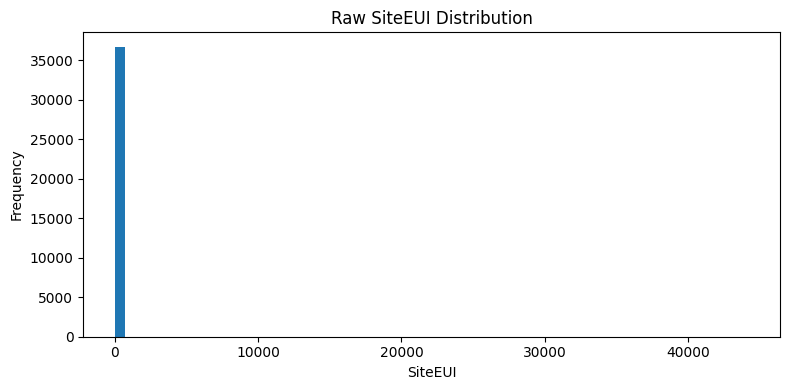

In [7]:
target_raw_numeric = pd.to_numeric(df_raw[TARGET_RAW], errors="coerce")

print("Raw SiteEUI descriptive statistics:")
display(target_raw_numeric.describe().to_frame("SiteEUI"))

if resolved_features.get("EPAPropertyType") is not None:
    epa_col = resolved_features["EPAPropertyType"]
    print("\nMost common EPA property types:")
    display(df_raw[epa_col].value_counts(dropna=False).head(20).to_frame("Count"))

plt.figure(figsize=(8, 4))
plt.hist(target_raw_numeric.dropna(), bins=60)
plt.xlabel("SiteEUI")
plt.ylabel("Frequency")
plt.title("Raw SiteEUI Distribution")
plt.tight_layout()
plt.show()